## simple RNN (predict sine -no noise)

In [1]:
import torch 
import torch.nn as nn
import torch.optim as opt
import matplotlib.pyplot as plt
import numpy as np


## data and data prep

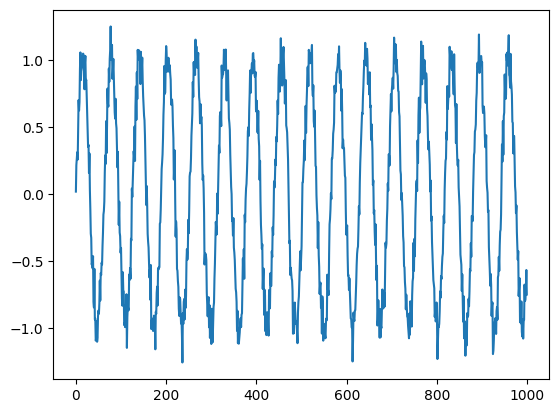

In [2]:
N = 1000

series = np.sin(0.1*np.arange(N)) + np.random.randn(N)*0.1
plt.plot(series)
plt.show()                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [3]:
T = 10
D = 1
S = 1
M = 128
layers = 5

In [4]:
X,y = [],[]
for t in range(N-T):
    X.append(series[t:t+T])
    y.append(series[t+T])

In [5]:
N = len(X)
X = np.array(X).reshape(-1,T,D)
y = np.array(y).reshape(-1,1)

In [6]:
X_train,X_test = X[:N//2],X[N//2:]
y_train,y_test = y[:N//2],y[N//2:]

In [7]:
X_train = torch.from_numpy(X_train.astype(np.float32))
X_test = torch.from_numpy(X_test.astype(np.float32))
y_train = torch.from_numpy(y_train.astype(np.float32))
y_test = torch.from_numpy(y_test.astype(np.float32))

In [8]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


# define SimpleRNN

In [9]:
class SimpleRNN(nn.Module):
    def __init__(self, num_of_inputs,num_of_layers,num_of_hidden,num_of_outputs,bidirectional=False,activation='relu'):
        super(SimpleRNN,self).__init__()
        self.D = num_of_inputs
        self.L = num_of_layers
        self.M = num_of_hidden
        self.K = num_of_outputs 
        self.rnn = nn.RNN(input_size=self.D,
                          hidden_size=self.M,
                          num_layers=self.L,
                          bidirectional=bidirectional,
                          nonlinearity=activation,
                          batch_first=True) # if true shape is NxTxD otherwise it's TxNxD
        if bidirectional:
             self.L *=2

             self.fc = nn.Linear(self.M*2,self.K)
        else:
             self.fc = nn.Linear(self.M,self.K)


    
    def forward(self,X):
            
            #X dim = NxTxD
            #h0 dimensions LxNxM
            h0 = torch.zeros(self.L,X.size(0),self.M).to(device)
        
            out,_ = self.rnn(X,h0) #out dimensions: NxTxM
            # dims x torch.Size([495, 10, 1]), h0: torch.Size([5, 495, 256]) out torch.Size([495, 10, 256])
            #we want fc  input to be NxM ->NxK     
            x = self.fc(out[:,-1,:])
            
            return x


## model init, train and etc.

In [10]:
model = SimpleRNN(num_of_inputs=D,num_of_layers=layers,num_of_hidden=M,num_of_outputs=1,bidirectional=False).to(device)
criterion = nn.MSELoss().to(device)
optimizer = opt.Adam(model.parameters(),lr=0.001)
# scheduler = opt.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer,mode='min',patience=10)

train

In [11]:
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

In [12]:
train_losses = []
test_losses = []

epochs = 1000
for epoch in range(epochs):
    optimizer.zero_grad()

    out = model(X_train)
    loss = criterion(out,y_train)
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    out = model(X_test)
    loss1 = criterion(out,y_test)
    test_losses.append(loss1.item())
    print(f'train loss: {train_losses[-1]} test loss {test_losses[-1]}')
    # scheduler.step(loss)

train loss: 0.5295606255531311 test loss 0.5220229625701904
train loss: 0.5213255882263184 test loss 0.5176509618759155
train loss: 0.5163986086845398 test loss 0.5126899480819702
train loss: 0.5110489726066589 test loss 0.5040207505226135
train loss: 0.5021581649780273 test loss 0.4908124506473541
train loss: 0.4889430105686188 test loss 0.47100168466567993
train loss: 0.46930113434791565 test loss 0.44281116127967834
train loss: 0.44121405482292175 test loss 0.40693366527557373
train loss: 0.4053378105163574 test loss 0.36353355646133423
train loss: 0.361996591091156 test loss 0.31226494908332825
train loss: 0.31093740463256836 test loss 0.25207969546318054
train loss: 0.25114110112190247 test loss 0.18905587494373322
train loss: 0.18907831609249115 test loss 0.1425969898700714
train loss: 0.14473889768123627 test loss 0.14785677194595337
train loss: 0.15210574865341187 test loss 0.14744716882705688
train loss: 0.151621013879776 test loss 0.09520584344863892
train loss: 0.10012627393

In [13]:
xs = [x for x in range(epochs)]

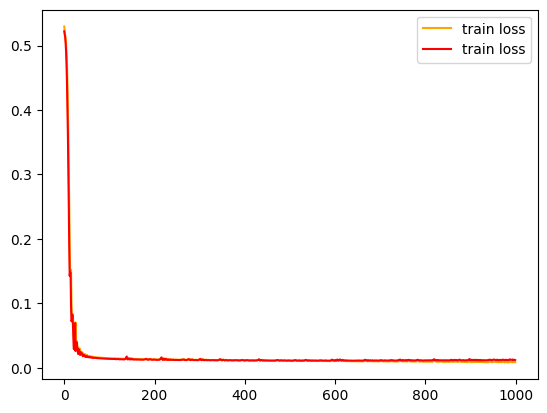

In [14]:
plt.plot(xs,train_losses,color='orange',label='train loss')
plt.plot(xs,test_losses,color='red',label='train loss')
plt.legend()
plt.show()

In [15]:
val_idx = 0 
validation_targets = y_test
validation_predictions = []
last_x = X_test[0]

In [16]:
while len(validation_predictions) < len(validation_targets) :
    inputs = last_x.view(1,-1,1)
    pred = model(inputs)
    validation_predictions.append(pred[0,0].item())
    val_idx += 1
    print(f'last_x.shape {last_x.shape} pred {pred.shape}')
    last_x = torch.cat((last_x[1:],pred))
  

last_x.shape torch.Size([10, 1]) pred torch.Size([1, 1])
last_x.shape torch.Size([10, 1]) pred torch.Size([1, 1])
last_x.shape torch.Size([10, 1]) pred torch.Size([1, 1])
last_x.shape torch.Size([10, 1]) pred torch.Size([1, 1])
last_x.shape torch.Size([10, 1]) pred torch.Size([1, 1])
last_x.shape torch.Size([10, 1]) pred torch.Size([1, 1])
last_x.shape torch.Size([10, 1]) pred torch.Size([1, 1])
last_x.shape torch.Size([10, 1]) pred torch.Size([1, 1])
last_x.shape torch.Size([10, 1]) pred torch.Size([1, 1])
last_x.shape torch.Size([10, 1]) pred torch.Size([1, 1])
last_x.shape torch.Size([10, 1]) pred torch.Size([1, 1])
last_x.shape torch.Size([10, 1]) pred torch.Size([1, 1])
last_x.shape torch.Size([10, 1]) pred torch.Size([1, 1])
last_x.shape torch.Size([10, 1]) pred torch.Size([1, 1])
last_x.shape torch.Size([10, 1]) pred torch.Size([1, 1])
last_x.shape torch.Size([10, 1]) pred torch.Size([1, 1])
last_x.shape torch.Size([10, 1]) pred torch.Size([1, 1])
last_x.shape torch.Size([10, 1]

C:\Users\liora\AppData\Local\Temp\ipykernel_30120\2382755765.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


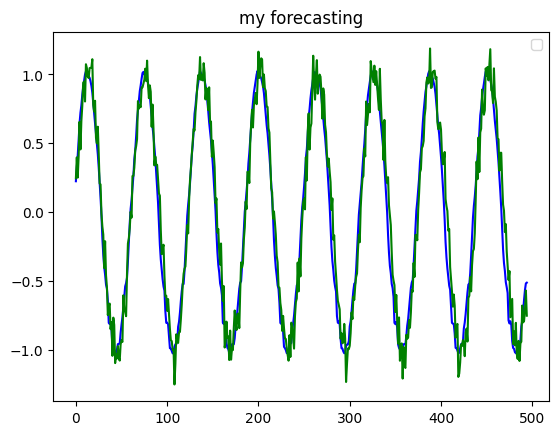

In [17]:
plt.title('my forecasting')
plt.plot(validation_predictions,color='blue')
plt.plot(validation_targets.detach().cpu().numpy(),color='green')
plt.legend()
plt.show()

In [18]:
#make predictions the right way
X_current = X_test[0]
predictions = []
for t in range(y_test.shape[0]):
    X_current = X_current.view(1, -1, 1)
    pred = model(X_current)
    predictions.append(pred.item())
    X_current = torch.cat((X_current.view(-1)[1:], pred.view(-1)))

[0.22371672093868256, 0.3240892291069031, 0.41169917583465576, 0.5196288824081421, 0.6445023417472839, 0.7219783067703247, 0.7750107645988464, 0.8511680960655212, 0.9076097011566162, 0.9555253386497498, 0.9992964863777161, 1.0214433670043945, 1.0035852193832397, 0.9925655126571655, 0.9859673976898193, 0.9754518270492554, 0.9507874846458435, 0.9156876802444458, 0.8670473098754883, 0.7930961847305298, 0.7154852151870728, 0.6370521783828735, 0.5772386789321899, 0.5018364191055298, 0.42013442516326904, 0.32483798265457153, 0.21387191116809845, 0.10601458698511124, -0.022193893790245056, -0.18818335235118866, -0.30864906311035156, -0.39946019649505615, -0.4546077251434326, -0.526888370513916, -0.5559763312339783, -0.6414864659309387, -0.8047470450401306, -0.8128241300582886, -0.8044174909591675, -0.8532487154006958, -0.9725203514099121, -0.9865645170211792, -1.0004034042358398, -1.023999810218811, -1.023847222328186, -0.9978984594345093, -0.9592161178588867, -0.9567946195602417, -0.95458710

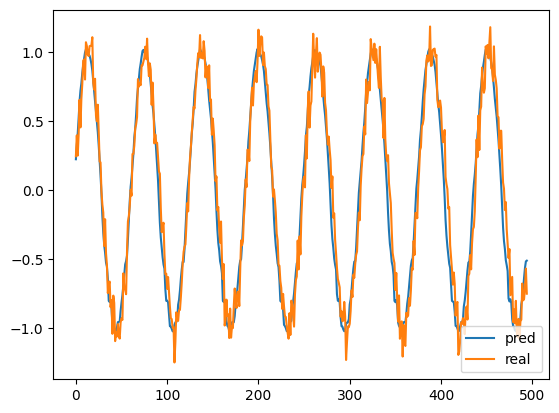

In [19]:
print(predictions)
plt.plot(predictions, label='pred')
plt.plot(y_test.detach().cpu().numpy(), label='real')
plt.legend()
plt.show()